<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/Loan_approval_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/loan_approval_dataset.csv')

In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
# Data Cleaning
# Checking duplicate values
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4264,False
4265,False
4266,False
4267,False


There are no Duplicate values.

In [ ]:
# Checking missing values
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


There are no missing values.


In [ ]:
# Checking outliers
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='income_annum'>

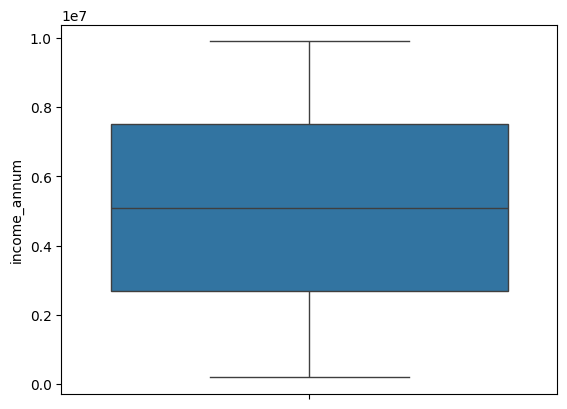

In [ ]:
df.columns = df.columns.str.strip()
sns.boxplot(df['income_annum'])

<Axes: ylabel='bank_asset_value'>

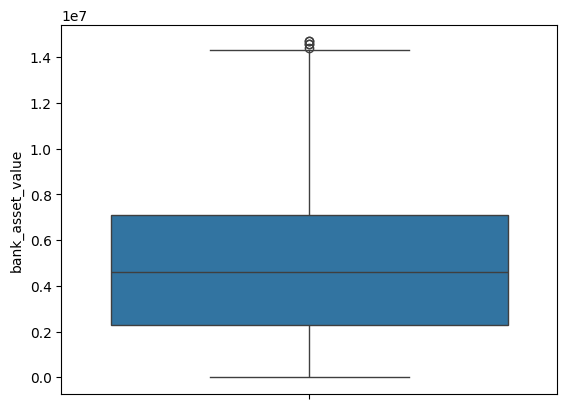

In [ ]:
sns.boxplot(df['bank_asset_value'])

<Axes: ylabel='loan_amount'>

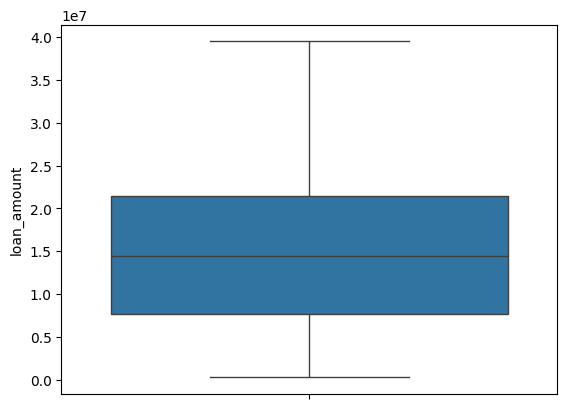

In [ ]:
sns.boxplot(df['loan_amount'])

<Axes: ylabel='loan_term'>

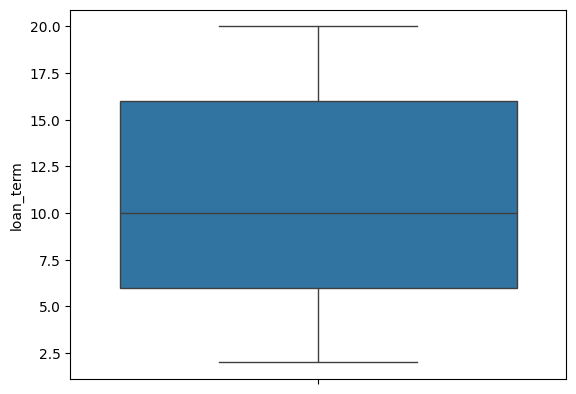

In [ ]:
sns.boxplot(df['loan_term'])

<Axes: ylabel='cibil_score'>

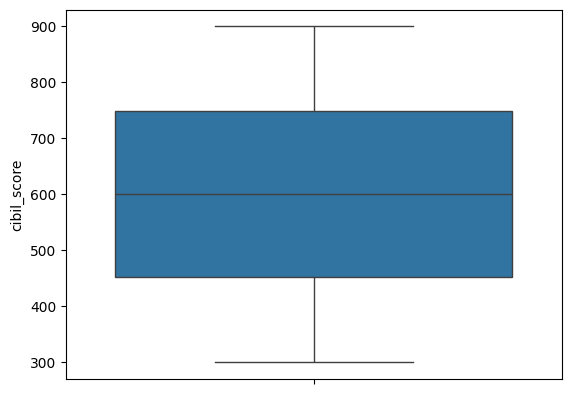

In [ ]:
sns.boxplot(df['cibil_score'])

<Axes: ylabel='residential_assets_value'>

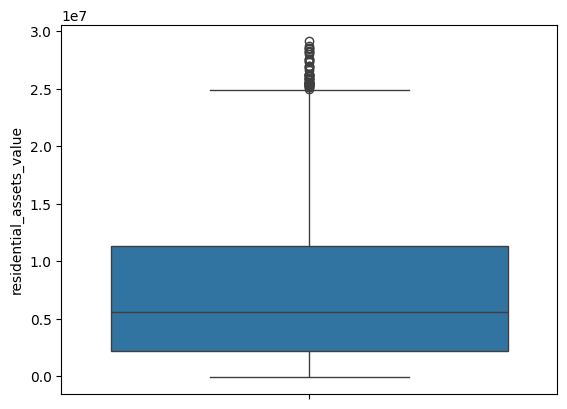

In [ ]:
sns.boxplot(df['residential_assets_value'])

<Axes: ylabel='commercial_assets_value'>

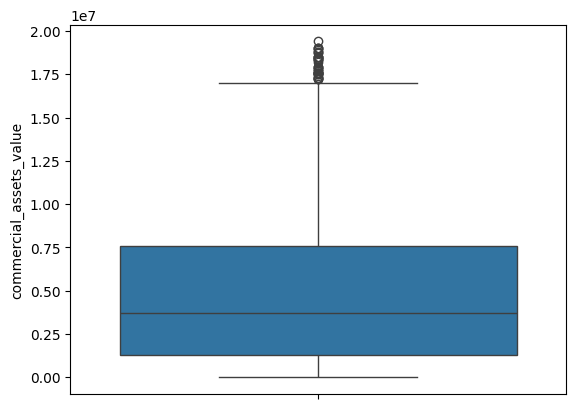

In [ ]:
sns.boxplot(df['commercial_assets_value'])

<Axes: ylabel='luxury_assets_value'>

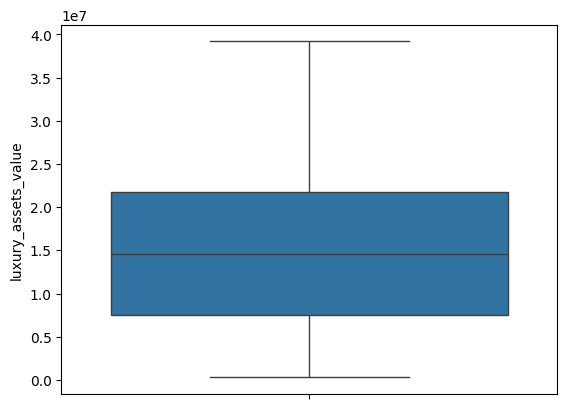

In [ ]:
sns.boxplot(df['luxury_assets_value'])

<Axes: ylabel='loan_status'>

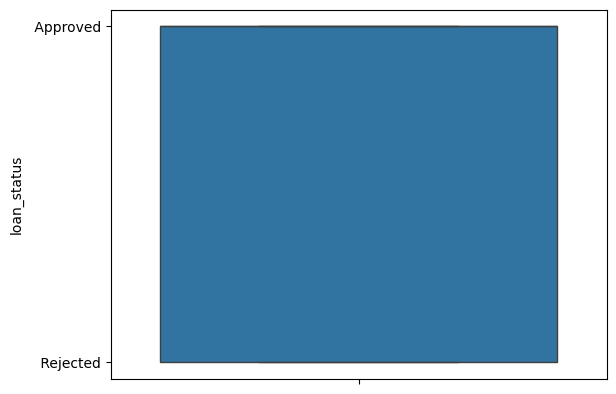

In [ ]:
sns.boxplot(df['loan_status'])

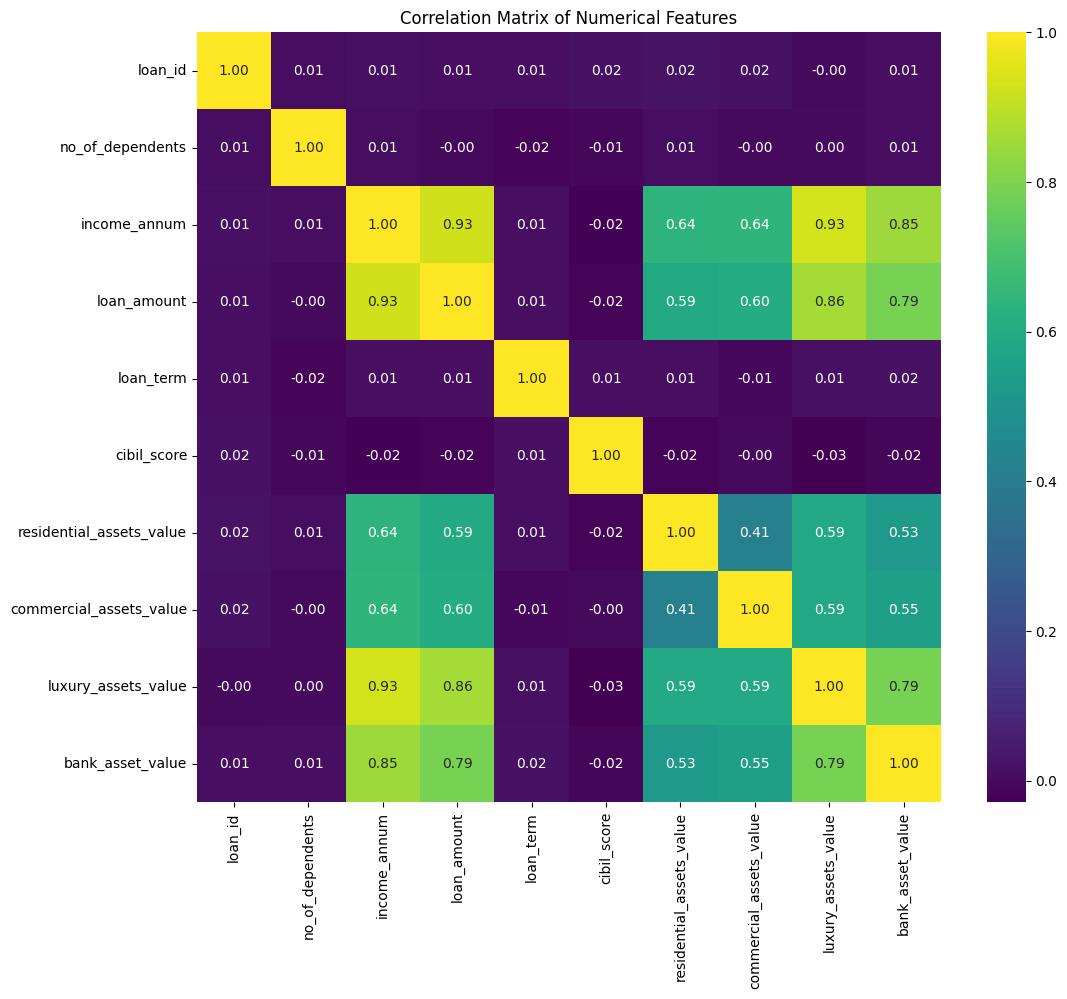

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
## these are highly correlated. when we go in machine model these may be insignificant.

Define Dependent and Independent Variables-
We will define the target variable y as 'loan_status' and the features X as all other columns, excluding 'loan_id'.

In [ ]:
y = df['loan_status']
x = df.drop(['loan_id', 'loan_status'],axis=1)

In [ ]:
x

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [ ]:
y

,loan_status
0,Approved
1,Rejected
2,Rejected
3,Rejected
4,Rejected
...,...
4264,Rejected
4265,Approved
4266,Rejected
4267,Approved


Train and Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state = 42)

In [ ]:
import statsmodels.api as sm
import pandas as pd

# Convert the target variable 'y' to numerical (0 and 1)
y_numeric = y.str.strip().map({'Rejected': 0, 'Approved': 1})

# Identify categorical columns for one-hot encoding
categorical_cols = ['education', 'self_employed']

# Apply one-hot encoding to the categorical columns in 'x'
x_encoded = pd.get_dummies(x, columns=categorical_cols, drop_first=True)

# Add a constant to the independent variables, which is required for statsmodels logistic regression
X_const = sm.add_constant(x_encoded)

# Explicitly convert all columns in X_const to numeric, coercing any errors to NaN.
# Then, fill any NaNs created by the coercion with 0, and ensure final type is float.
for col in X_const.columns:
    X_const[col] = pd.to_numeric(X_const[col], errors='coerce').fillna(0).astype(float)

# Create and fit the logistic regression model using the numerical target variable
logit_model = sm.Logit(y_numeric, X_const)
result = logit_model.fit()

# Display the model summary
display(result.summary())

Optimization terminated successfully.
         Current function value: 0.219924
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4257
Method:                           MLE   Df Model:                           11
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6683
Time:                        03:02:02   Log-Likelihood:                -938.86
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      -11.3077      0.438    -25.833      0.000     -12.166     -10.450
no_of_dependents            -0.0178      0.035     -0.510      0.610      -0.086       0.051
income_annum             -6.137e-07   9.08e-08     -6.758      0.000   -7.92e-07   -4.36e-07
loan_amount               1.447e-07   1.81e-08      7.986      0.000    1.09e-07     1.8e-07
loan_term                   -0.1516      0.011    -13.253      0.000      -0.174      -0.129
cibil_score                  0.0248      0.001     29.612      0.000       0.023       0.026
residential_assets_value  2.923e-09   1.19e-08      0.246      0.806   -2.03e-08    2.62e-08
commercial_assets_value   1.903e-08   1.73e-08      1.101      0.271   -1.49e-08    5.29e-08
luxury_assets_value        3.13e-08   1.75e-08      1.789      0.074   -2.98e-09    6.56e-08
bank_asset_value          5.076e-08   3.34e-08      1.519      0.129   -1.47e-08    1.16e-07
education_ Not Graduate     -0.1153      0.118     -0.975      0.330      -0.347       0.117
self_employed_ Yes           0.0674      0.118      0.570      0.568      -0.164       0.299
============================================================================================
"""

In [ ]:
import statsmodels.api as sm
import pandas as pd

X_modified = x.drop(columns=['residential_assets_value'])

# Identify categorical columns for one-hot encoding in X_modified
categorical_cols_modified = ['education', 'self_employed']

# Apply one-hot encoding to the categorical columns in X_modified
X_modified_encoded = pd.get_dummies(X_modified, columns=categorical_cols_modified, drop_first=True)

# Add a constant to the modified independent variables
X_modified_const = sm.add_constant(X_modified_encoded)

# Explicitly convert all columns in X_modified_const to numeric, coercing any errors to NaN.
# Then, fill any NaNs created by the coercion with 0, and ensure final type is float.
for col in X_modified_const.columns:
    X_modified_const[col] = pd.to_numeric(X_modified_const[col], errors='coerce').fillna(0).astype(float)

# Convert the target variable 'y' to numerical (0 and 1)
y_numeric_modified = y.str.strip().map({'Rejected': 0, 'Approved': 1})

# Create and fit the logistic regression model using the numerical target variable
logit_model_modified = sm.Logit(y_numeric_modified, X_modified_const)
result_modified = logit_model_modified.fit()

# Display the modified model summary
display(result_modified.summary())

Optimization terminated successfully.
         Current function value: 0.219931
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4258
Method:                           MLE   Df Model:                           10
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6683
Time:                        03:02:25   Log-Likelihood:                -938.89
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     -11.3072      0.438    -25.829      0.000     -12.165     -10.449
no_of_dependents           -0.0178      0.035     -0.509      0.611      -0.086       0.051
income_annum            -6.092e-07    8.9e-08     -6.847      0.000   -7.84e-07   -4.35e-07
loan_amount               1.45e-07   1.81e-08      8.008      0.000    1.09e-07     1.8e-07
loan_term                  -0.1517      0.011    -13.257      0.000      -0.174      -0.129
cibil_score                 0.0248      0.001     29.611      0.000       0.023       0.026
commercial_assets_value  1.902e-08   1.73e-08      1.101      0.271   -1.49e-08    5.29e-08
luxury_assets_value      3.123e-08   1.75e-08      1.786      0.074   -3.04e-09    6.55e-08
bank_asset_value         5.011e-08   3.33e-08      1.504      0.133   -1.52e-08    1.15e-07
education_ Not Graduate    -0.1151      0.118     -0.973      0.331      -0.347       0.117
self_employed_ Yes          0.0679      0.118      0.574      0.566      -0.164       0.299
===========================================================================================
"""

In [ ]:
import statsmodels.api as sm
import pandas as pd

X_modified_2 = x.drop(columns=['residential_assets_value', 'no_of_dependents'])

# Identify categorical columns for one-hot encoding in X_modified_2
categorical_cols_modified_2 = ['education', 'self_employed']

# Apply one-hot encoding to the categorical columns in X_modified_2
X_modified_encoded_2 = pd.get_dummies(X_modified_2, columns=categorical_cols_modified_2, drop_first=True)

# Add a constant to the modified independent variables
X_modified_const_2 = sm.add_constant(X_modified_encoded_2)

# Explicitly convert all columns in X_modified_const_2 to numeric, coercing any errors to NaN.
# Then, fill any NaNs created by the coercion with 0, and ensure final type is float.
for col in X_modified_const_2.columns:
    X_modified_const_2[col] = pd.to_numeric(X_modified_const_2[col], errors='coerce').fillna(0).astype(float)

# Convert the target variable 'y' to numerical (0 and 1)
y_numeric_modified_2 = y.str.strip().map({'Rejected': 0, 'Approved': 1})

# Create and fit the logistic regression model
logit_model_modified_2 = sm.Logit(y_numeric_modified_2, X_modified_const_2)
result_modified_2 = logit_model_modified_2.fit()

# Display the modified model summary
display(result_modified_2.summary())

Optimization terminated successfully.
         Current function value: 0.219962
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4259
Method:                           MLE   Df Model:                            9
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6682
Time:                        03:03:28   Log-Likelihood:                -939.02
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     -11.3560      0.428    -26.545      0.000     -12.195     -10.518
income_annum            -6.098e-07   8.89e-08     -6.859      0.000   -7.84e-07   -4.36e-07
loan_amount              1.451e-07   1.81e-08      8.018      0.000     1.1e-07    1.81e-07
loan_term                  -0.1516      0.011    -13.248      0.000      -0.174      -0.129
cibil_score                 0.0248      0.001     29.620      0.000       0.023       0.026
commercial_assets_value  1.879e-08   1.73e-08      1.087      0.277   -1.51e-08    5.26e-08
luxury_assets_value      3.149e-08   1.75e-08      1.801      0.072   -2.77e-09    6.57e-08
bank_asset_value             5e-08   3.33e-08      1.501      0.133   -1.53e-08    1.15e-07
education_ Not Graduate    -0.1118      0.118     -0.946      0.344      -0.343       0.120
self_employed_ Yes          0.0670      0.118      0.568      0.570      -0.164       0.299
===========================================================================================
"""

In [ ]:
import statsmodels.api as sm
import pandas as pd

X_modified_3 = x.drop(columns=['residential_assets_value', 'no_of_dependents', 'self_employed'])

# Identify categorical columns for one-hot encoding in X_modified_3
categorical_cols_modified_3 = ['education'] # Only 'education' remains categorical

# Apply one-hot encoding to the categorical columns in X_modified_3
X_modified_encoded_3 = pd.get_dummies(X_modified_3, columns=categorical_cols_modified_3, drop_first=True)

# Add a constant to the modified independent variables
X_modified_const_3 = sm.add_constant(X_modified_encoded_3)

# Explicitly convert all columns in X_modified_const_3 to numeric, coercing any errors to NaN.
# Then, fill any NaNs created by the coercion with 0, and ensure final type is float.
for col in X_modified_const_3.columns:
    X_modified_const_3[col] = pd.to_numeric(X_modified_const_3[col], errors='coerce').fillna(0).astype(float)

# Convert the target variable 'y' to numerical (0 and 1)
y_numeric_modified_3 = y.str.strip().map({'Rejected': 0, 'Approved': 1})

# Create and fit the logistic regression model
logit_model_modified_3 = sm.Logit(y_numeric_modified_3, X_modified_const_3)
result_modified_3 = logit_model_modified_3.fit()

# Display the modified model summary
display(result_modified_3.summary())

Optimization terminated successfully.
         Current function value: 0.220000
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4260
Method:                           MLE   Df Model:                            8
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6682
Time:                        03:03:29   Log-Likelihood:                -939.18
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     -11.3224      0.423    -26.751      0.000     -12.152     -10.493
income_annum             -6.11e-07   8.89e-08     -6.875      0.000   -7.85e-07   -4.37e-07
loan_amount              1.451e-07   1.81e-08      8.023      0.000     1.1e-07    1.81e-07
loan_term                  -0.1515      0.011    -13.247      0.000      -0.174      -0.129
cibil_score                 0.0248      0.001     29.612      0.000       0.023       0.026
commercial_assets_value  1.848e-08   1.73e-08      1.070      0.285   -1.54e-08    5.23e-08
luxury_assets_value      3.168e-08   1.75e-08      1.812      0.070   -2.58e-09    6.59e-08
bank_asset_value         5.036e-08   3.33e-08      1.513      0.130   -1.49e-08    1.16e-07
education_ Not Graduate    -0.1096      0.118     -0.928      0.353      -0.341       0.122
===========================================================================================
"""

In [ ]:
import statsmodels.api as sm
import pandas as pd

X_modified_4 = x.drop(columns=['residential_assets_value', 'no_of_dependents', 'self_employed', 'education'])

# At this point, no categorical columns are left in X_modified_4, so no one-hot encoding is needed.
# Add a constant to the modified independent variables
X_modified_const_4 = sm.add_constant(X_modified_4)

# Explicitly convert all columns in X_modified_const_4 to numeric, coercing any errors to NaN.
# Then, fill any NaNs created by the coercion with 0, and ensure final type is float.
for col in X_modified_const_4.columns:
    X_modified_const_4[col] = pd.to_numeric(X_modified_const_4[col], errors='coerce').fillna(0).astype(float)

# Convert the target variable 'y' to numerical (0 and 1)
y_numeric_modified_4 = y.str.strip().map({'Rejected': 0, 'Approved': 1})

# Create and fit the logistic regression model
logit_model_modified_4 = sm.Logit(y_numeric_modified_4, X_modified_const_4)
result_modified_4 = logit_model_modified_4.fit()

# Display the modified model summary
display(result_modified_4.summary())

Optimization terminated successfully.
         Current function value: 0.220101
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4261
Method:                           MLE   Df Model:                            7
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6680
Time:                        03:03:30   Log-Likelihood:                -939.61
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     -11.3727      0.420    -27.056      0.000     -12.197     -10.549
income_annum            -6.107e-07   8.89e-08     -6.870      0.000   -7.85e-07   -4.36e-07
loan_amount               1.45e-07   1.81e-08      8.015      0.000     1.1e-07     1.8e-07
loan_term                  -0.1512      0.011    -13.236      0.000      -0.174      -0.129
cibil_score                 0.0248      0.001     29.626      0.000       0.023       0.026
commercial_assets_value  1.794e-08   1.73e-08      1.039      0.299   -1.59e-08    5.18e-08
luxury_assets_value      3.183e-08   1.75e-08      1.820      0.069   -2.44e-09    6.61e-08
bank_asset_value         5.085e-08   3.33e-08      1.527      0.127   -1.44e-08    1.16e-07
===========================================================================================
"""

In [ ]:
import statsmodels.api as sm
import pandas as pd

X_modified_5 = x.drop(columns=['residential_assets_value', 'no_of_dependents', 'self_employed', 'education', 'commercial_assets_value'])

# At this point, no categorical columns are left in X_modified_5, so no one-hot encoding is needed.
# Add a constant to the modified independent variables
X_modified_const_5 = sm.add_constant(X_modified_5)

# Explicitly convert all columns in X_modified_const_5 to numeric, coercing any errors to NaN.
# Then, fill any NaNs created by the coercion with 0, and ensure final type is float.
for col in X_modified_const_5.columns:
    X_modified_const_5[col] = pd.to_numeric(X_modified_const_5[col], errors='coerce').fillna(0).astype(float)

# Convert the target variable 'y' to numerical (0 and 1)
y_numeric_modified_5 = y.str.strip().map({'Rejected': 0, 'Approved': 1})

# Create and fit the logistic regression model
logit_model_modified_5 = sm.Logit(y_numeric_modified_5, X_modified_const_5)
result_modified_5 = logit_model_modified_5.fit()

# Display the modified model summary
display(result_modified_5.summary())

Optimization terminated successfully.
         Current function value: 0.220227
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4262
Method:                           MLE   Df Model:                            6
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6678
Time:                        03:03:30   Log-Likelihood:                -940.15
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -11.3687      0.420    -27.054      0.000     -12.192     -10.545
income_annum        -5.957e-07   8.76e-08     -6.801      0.000   -7.67e-07   -4.24e-07
loan_amount          1.456e-07   1.81e-08      8.057      0.000     1.1e-07    1.81e-07
loan_term              -0.1514      0.011    -13.262      0.000      -0.174      -0.129
cibil_score             0.0248      0.001     29.621      0.000       0.023       0.026
luxury_assets_value  3.228e-08   1.75e-08      1.849      0.064   -1.93e-09    6.65e-08
bank_asset_value         5e-08   3.33e-08      1.503      0.133   -1.52e-08    1.15e-07
=======================================================================================
"""

In [ ]:
import statsmodels.api as sm
import pandas as pd

X_modified_6 = x.drop(columns=['residential_assets_value', 'no_of_dependents', 'self_employed', 'education', 'commercial_assets_value', 'bank_asset_value'])

# At this point, no categorical columns are left in X_modified_6, so no one-hot encoding is needed.
# Add a constant to the modified independent variables
X_modified_const_6 = sm.add_constant(X_modified_6)

# Explicitly convert all columns in X_modified_const_6 to numeric, coercing any errors to NaN.
# Then, fill any NaNs created by the coercion with 0, and ensure final type is float.
for col in X_modified_const_6.columns:
    X_modified_const_6[col] = pd.to_numeric(X_modified_const_6[col], errors='coerce').fillna(0).astype(float)

# Convert the target variable 'y' to numerical (0 and 1)
y_numeric_modified_6 = y.str.strip().map({'Rejected': 0, 'Approved': 1})

# Create and fit the logistic regression model
logit_model_modified_6 = sm.Logit(y_numeric_modified_6, X_modified_const_6)
result_modified_6 = logit_model_modified_6.fit()

# Display the modified model summary
display(result_modified_6.summary())

Optimization terminated successfully.
         Current function value: 0.220492
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4263
Method:                           MLE   Df Model:                            5
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6674
Time:                        03:03:31   Log-Likelihood:                -941.28
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -11.3560      0.420    -27.059      0.000     -12.179     -10.533
income_annum        -5.435e-07      8e-08     -6.790      0.000      -7e-07   -3.87e-07
loan_amount          1.449e-07   1.81e-08      8.020      0.000    1.09e-07     1.8e-07
loan_term              -0.1509      0.011    -13.241      0.000      -0.173      -0.129
cibil_score             0.0248      0.001     29.638      0.000       0.023       0.026
luxury_assets_value  3.201e-08   1.74e-08      1.835      0.067   -2.19e-09    6.62e-08
=======================================================================================
"""

In [ ]:
import statsmodels.api as sm
import pandas as pd

X_modified_7 = x.drop(columns=['residential_assets_value', 'no_of_dependents', 'self_employed', 'education', 'commercial_assets_value', 'bank_asset_value', 'luxury_assets_value'])

# At this point, no categorical columns are left in X_modified_7, so no one-hot encoding is needed.
# Add a constant to the modified independent variables
X_modified_const_7 = sm.add_constant(X_modified_7)

# Explicitly convert all columns in X_modified_const_7 to numeric, coercing any errors to NaN.
# Then, fill any NaNs created by the coercion with 0, and ensure final type is float.
for col in X_modified_const_7.columns:
    X_modified_const_7[col] = pd.to_numeric(X_modified_const_7[col], errors='coerce').fillna(0).astype(float)

# Convert the target variable 'y' to numerical (0 and 1)
y_numeric_modified_7 = y.str.strip().map({'Rejected': 0, 'Approved': 1})

# Create and fit the logistic regression model
logit_model_modified_7 = sm.Logit(y_numeric_modified_7, X_modified_const_7)
result_modified_7 = logit_model_modified_7.fit()

# Display the modified model summary
display(result_modified_7.summary())

Optimization terminated successfully.
         Current function value: 0.220887
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4264
Method:                           MLE   Df Model:                            4
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.6668
Time:                        03:03:32   Log-Likelihood:                -942.97
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -11.3442      0.419    -27.070      0.000     -12.166     -10.523
income_annum -4.436e-07   5.83e-08     -7.614      0.000   -5.58e-07   -3.29e-07
loan_amount   1.443e-07    1.8e-08      8.000      0.000    1.09e-07     1.8e-07
loan_term       -0.1496      0.011    -13.191      0.000      -0.172      -0.127
cibil_score      0.0247      0.001     29.664      0.000       0.023       0.026
================================================================================
"""